# Metastatic Clonal Selection Classifier + SHAP Analysis

**Research question:** Among mutations/copy-number events that were subclonal in the primary tumor, which ones get selected (become clonal) in the metastasis? What features predict this?

**Data:** `binary_selection_dataset.csv` 

**Method:** Leave-one-patient-out cross-validation (never split events from the same patient across train/test — patients contribute many correlated events, so random splitting would leak information and inflate performance). Two feature sets are compared:
- **Event-only** — the event's own molecular identity (gene/locus, category, deleteriousness, metastatic site)
- **Full** — event-level features plus patient-level context (evolutionary subtype, wGII, ITH Index, stage, etc.)



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay

df = pd.read_csv("binary_selection_dataset.csv")
print("Dataset shape:", df.shape)
print("Positive rate:", df["label"].mean())

C:\Users\user\anaconda3\envs\Metastasis\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (1195, 25)
Positive rate: 0.3682008368200837


## 1. Feature preparation


In [4]:
top_genes = df['gene_or_locus'].value_counts().head(15).index
df['gene_or_locus_bucketed'] = df['gene_or_locus'].where(df['gene_or_locus'].isin(top_genes), 'Other')
df['deleterious'] = df['deleterious'].fillna('NA_SCNA')
df['exonic_function'] = df['exonic_function'].fillna('NA_SCNA')
df['Progression group'] = df['Progression group'].fillna('Unknown')

EVENT_CAT = ['event_category', 'event_subtype', 'gene_or_locus_bucketed', 'deleterious', 'exonic_function', 'met_site']
PATIENT_CAT = ['Sex', 'Histology', 'Sarcomatoid change (Y/N)', 'Overall Stage',
               'Evolutionary subtype', 'ITH/WGII group', 'Progression group']
PATIENT_NUM = ['Age', 'Fuhrman Grade', 'Size of primary tumour (mm)', 'wGII', 'ITH Index']

y = df['label'].values
groups = df['patient'].values

## 2. Model comparison under leave-one-patient-out cross-validation


In [6]:
def build_pipeline(cat_cols, num_cols, model):
    transformers = [('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)]
    if num_cols:
        transformers.append(('num', StandardScaler(), num_cols))
    pre = ColumnTransformer(transformers)
    from sklearn.pipeline import Pipeline
    return Pipeline([('pre', pre), ('model', model)])


def evaluate(cat_cols, num_cols, model_ctor, label):
    X = df[cat_cols + num_cols]
    oof_pred = np.zeros(len(df))
    logo = LeaveOneGroupOut()
    for train_idx, test_idx in logo.split(X, y, groups):
        pipe = build_pipeline(cat_cols, num_cols, model_ctor())
        pipe.fit(X.iloc[train_idx], y[train_idx])
        oof_pred[test_idx] = pipe.predict_proba(X.iloc[test_idx])[:, 1]
    auc = roc_auc_score(y, oof_pred)
    ap = average_precision_score(y, oof_pred)
    print(f"{label:40s} ROC-AUC={auc:.3f}   PR-AUC={ap:.3f}")
    return oof_pred

print(f"{'Model':40s} {'Metric':>8}\n" + "-"*60)
_ = evaluate([], [], lambda: DummyClassifier(strategy='most_frequent'), "Baseline (majority class)")
_ = evaluate(EVENT_CAT, [], lambda: LogisticRegression(max_iter=1000, class_weight='balanced'), "Event-only, LogisticRegression")
oof_event_rf = evaluate(EVENT_CAT, [], lambda: RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=5, class_weight='balanced', random_state=42), "Event-only, RandomForest")
_ = evaluate(EVENT_CAT + PATIENT_CAT, PATIENT_NUM, lambda: LogisticRegression(max_iter=1000, class_weight='balanced'), "Full features, LogisticRegression")
oof_full_rf = evaluate(EVENT_CAT + PATIENT_CAT, PATIENT_NUM, lambda: RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=5, class_weight='balanced', random_state=42), "Full features, RandomForest")

Model                                      Metric
------------------------------------------------------------
Baseline (majority class)                ROC-AUC=0.500   PR-AUC=0.368
Event-only, LogisticRegression           ROC-AUC=0.572   PR-AUC=0.447
Event-only, RandomForest                 ROC-AUC=0.583   PR-AUC=0.450
Full features, LogisticRegression        ROC-AUC=0.583   PR-AUC=0.410
Full features, RandomForest              ROC-AUC=0.600   PR-AUC=0.406


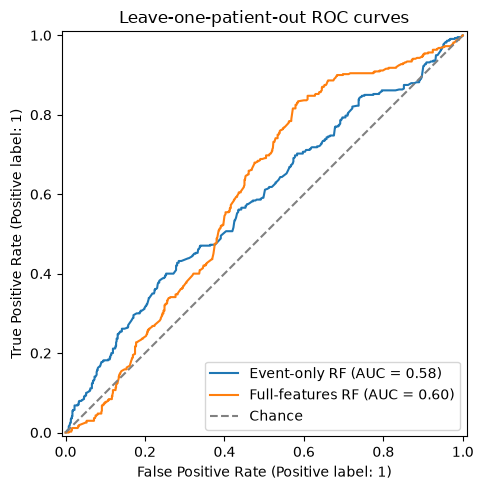

In [15]:
fig, ax = plt.subplots(figsize=(5, 5))
RocCurveDisplay.from_predictions(y, oof_event_rf, name="Event-only RF", ax=ax)
RocCurveDisplay.from_predictions(y, oof_full_rf, name="Full-features RF", ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title("Leave-one-patient-out ROC curves")
ax.legend()
plt.tight_layout()

plt.savefig(
    'ROC_Curves.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

## 3. SHAP analysis — event-only model


In [9]:
pre_event = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), EVENT_CAT)])
X_event = pre_event.fit_transform(df[EVENT_CAT]).astype(float)
feat_names_event = pre_event.get_feature_names_out()

model_event = RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5, class_weight='balanced', random_state=42)
model_event.fit(X_event, y)

explainer_event = shap.TreeExplainer(model_event)
sv_event = np.array(explainer_event.shap_values(X_event))
sv_event_pos = sv_event[:, :, 1] if sv_event.ndim == 3 else sv_event

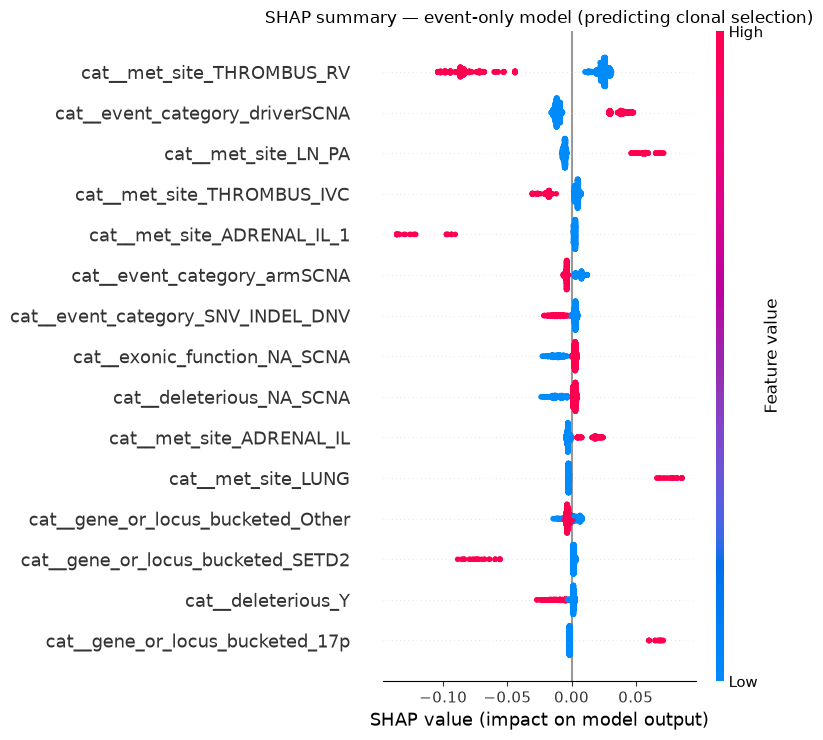

In [13]:
shap.summary_plot(sv_event_pos, X_event, feature_names=feat_names_event, max_display=15, show=False)
plt.title("SHAP summary — event-only model (predicting clonal selection)")
plt.tight_layout()
plt.savefig(
    'shap event only.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## 4. SHAP analysis — full model (event + patient context)


In [11]:
pre_full = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), EVENT_CAT + PATIENT_CAT),
    ('num', StandardScaler(), PATIENT_NUM),
])
X_full = pre_full.fit_transform(df[EVENT_CAT + PATIENT_CAT + PATIENT_NUM]).astype(float)
feat_names_full = pre_full.get_feature_names_out()

model_full = RandomForestClassifier(n_estimators=300, max_depth=5, min_samples_leaf=5, class_weight='balanced', random_state=42)
model_full.fit(X_full, y)

explainer_full = shap.TreeExplainer(model_full)
sv_full = np.array(explainer_full.shap_values(X_full))
sv_full_pos = sv_full[:, :, 1] if sv_full.ndim == 3 else sv_full

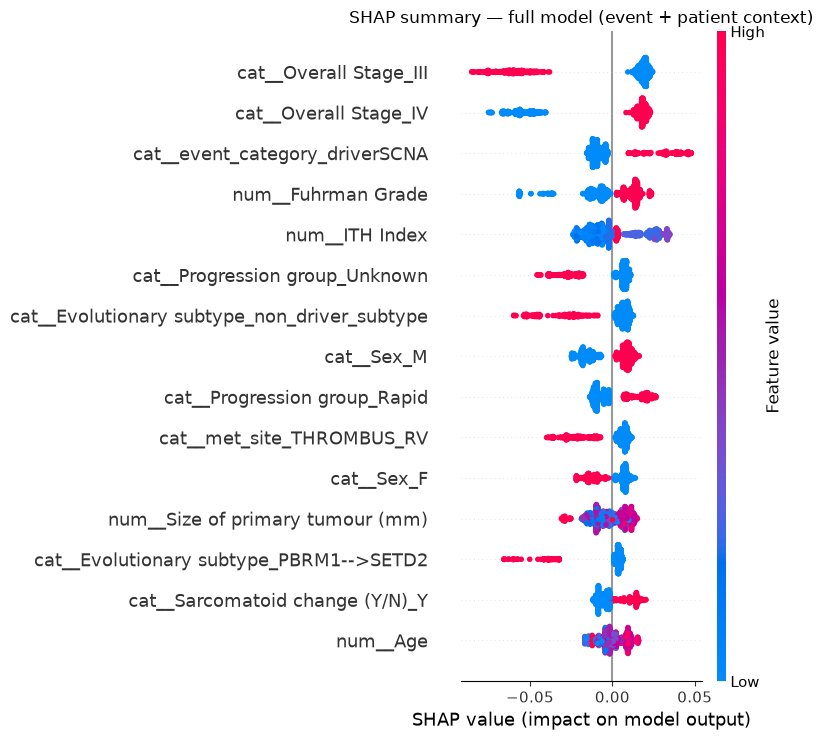

In [14]:
shap.summary_plot(sv_full_pos, X_full, feature_names=feat_names_full, max_display=15, show=False)
plt.title("SHAP summary — full model (event + patient context)")
plt.tight_layout()

plt.savefig(
    'shap_event_full_model.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()